<a href="https://colab.research.google.com/github/mxsry/Sign-Language-Recognition-Using-Deep-Convolutional-Neural-Networks/blob/main/CSCU9M6_Natural_Language_Processing_and_Computer_Vision_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing needed library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

Data Loading and Preprocessing

In [ ]:
# Load the dataset
df_test = pd.read_csv('sign_mnist_test.csv')
df_train = pd.read_csv('sign_mnist_train.csv')

In [ ]:
# Convert to numpy array
x_train = df_train.drop('label', axis=1).values
y_train = df_train['label'].values

x_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

In [ ]:
# Identify how many class
uni = np.unique(y_train)
len(uni)

24

In [ ]:
print("X_train shape: ",x_train.shape)
print("X_test shape: ",x_test.shape)

X_train shape:  (27455, 784)
X_test shape:  (7172, 784)


In [ ]:
# Convert pixel values into image tensors
# x_train = tf.convert_to_tensor(x_train)
# y_train = tf.convert_to_tensor(y_train)
# x_test = tf.convert_to_tensor(x_test)
# y_test = tf.convert_to_tensor(y_test)

In [ ]:
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
# Validation set from training set
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=36)

In [ ]:
# Reshape 2
x_val = x_val.reshape(-1,28,28,1)

 CNN Architectures


In [ ]:
# Import needed libraries
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
from keras.optimizers import RMSprop,Adam

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPool2D(2, 2))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(2, 2))

# Block 3
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(25, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,825 (518.85 KB)

 Trainable params: 132,825 (518.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size = 32, validation_data=(x_val, y_val))

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.3662 - loss: 2.0069 - val_accuracy: 0.8203 - val_loss: 0.6559
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.7615 - loss: 0.6942 - val_accuracy: 0.9461 - val_loss: 0.2254
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.8591 - loss: 0.4013 - val_accuracy: 0.9823 - val_loss: 0.0979
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9048 - loss: 0.2760 - val_accuracy: 0.9949 - val_loss: 0.0521
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.9332 - loss: 0.1995 - val_accuracy: 0.9995 - val_loss: 0.0262
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9447 - loss: 0.1629 - val_accuracy: 0.9978 - val_loss: 0.0224
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step - accuracy: 0.9547 - loss: 0.1351 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9602 - loss: 0.1185 - 

In [ ]:
VGG = Sequential()

# Block 1
VGG.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
VGG.add(BatchNormalization())
VGG.add(Conv2D(32, (3,3), activation='relu', padding='same'))
VGG.add(MaxPool2D(pool_size=(2,2)))
VGG.add(Dropout(0.25))

# Block 2
VGG.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGG.add(BatchNormalization())
VGG.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGG.add(MaxPool2D(pool_size=(2,2)))
VGG.add(Dropout(0.25))

# Fully Connected
VGG.add(Flatten())
VGG.add(Dense(256, activation='relu'))
VGG.add(Dropout(0.5))
VGG.add(Dense(25, activation='softmax'))

In [ ]:
VGG.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
VGG.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 874,873 (3.34 MB)

 Trainable params: 874,681 (3.34 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history_VGG = VGG.fit(x_train, y_train, epochs=10, batch_size = 32, validation_data=(x_val, y_val))

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 115s 163ms/step - accuracy: 0.3215 - loss: 2.0674 - val_accuracy: 0.7958 - val_loss: 0.8102
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 141s 162ms/step - accuracy: 0.6089 - loss: 1.0458 - val_accuracy: 0.9639 - val_loss: 0.1703
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 147s 170ms/step - accuracy: 0.7726 - loss: 0.6109 - val_accuracy: 0.9836 - val_loss: 0.0644
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 111s 162ms/step - accuracy: 0.8966 - loss: 0.2882 - val_accuracy: 0.9922 - val_loss: 0.0282
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 110s 161ms/step - accuracy: 0.9419 - loss: 0.1653 - val_accuracy: 0.9996 - val_loss: 0.0023
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 143s 161ms/step - accuracy: 0.9671 - loss: 0.0941 - val_accuracy: 0.9954 - val_loss: 0.0153
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 111s 162ms/step - accuracy: 0.9751 - loss: 0.0765 - val_accuracy: 0.9987 - val_loss: 0.0028
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 117s 171ms/step - accuracy: 0.9814 -

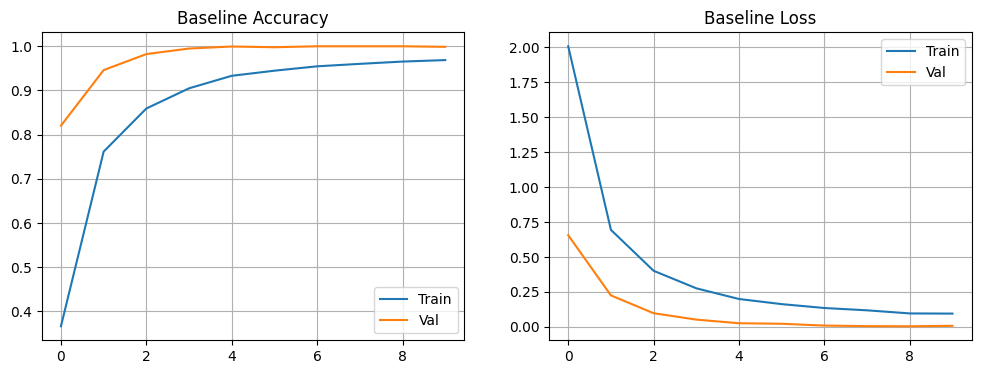

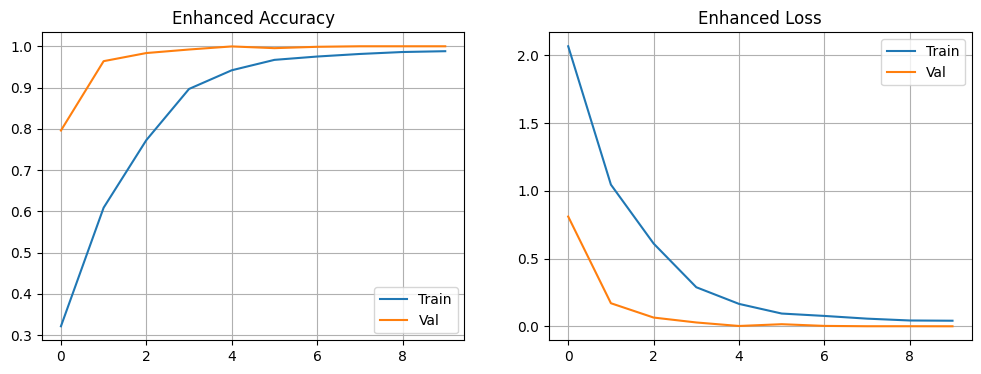

In [ ]:
# Plot training vs validation accuracy/loss

def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(title + " Accuracy")
    plt.legend()
    plt.grid()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(title + " Loss")
    plt.legend()
    plt.grid()

    plt.show()

plot_history(history, "Baseline")
plot_history(history_VGG, "Enhanced")

In [ ]:
y_pred = np.argmax(VGG.predict(x_test), axis=1)
y_pred

225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step


array([ 6,  5, 10, ...,  2,  4,  2])

In [ ]:
# Test Overfitting
test_loss, test_accuracy = VGG.evaluate(x_test, y_test, verbose=1)
test_loss1, test_accuracy1 = model.evaluate(x_test, y_test, verbose=1)

# Testing on VGG Model
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Testing on Baseline Model
print(f"Test Loss: {test_loss1:.4f}")
print(f"Test Accuracy: {test_accuracy1:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9859 - loss: 0.0551
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9414 - loss: 0.2339
Test Loss: 0.0551
Test Accuracy: 0.9859
Test Loss: 0.2339
Test Accuracy: 0.9414


In [ ]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score


In [ ]:
# Precision, Recall, F1-Score and Confusion Matrix
ps = precision_score(y_test, y_pred, average='macro')
rs = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

# Calculate Average Score
print("Average Score:")
print(f"Precision: {ps:.4f}")
print(f"Recall: {rs:.4f}")
print(f"F1 Score: {f1:.4f}")

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

Average Score:
Precision: 0.9874
Recall: 0.9848
F1 Score: 0.9851

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       1.00      1.00      1.00       245
           4       1.00      1.00      1.00       498
           5       1.00      1.00      1.00       247
           6       1.00      0.99      0.99       348
           7       0.99      1.00      0.99       436
           8       0.95      1.00      0.97       288
          10       1.00      0.94      0.97       331
          11       1.00      1.00      1.00       209
          12       0.94      1.00      0.97       394
          13       1.00      0.92      0.96       291
          14       1.00      1.00      1.00       246
          15       1.00      1.00      1.00       347
          16       1.00      1.00      1.00  

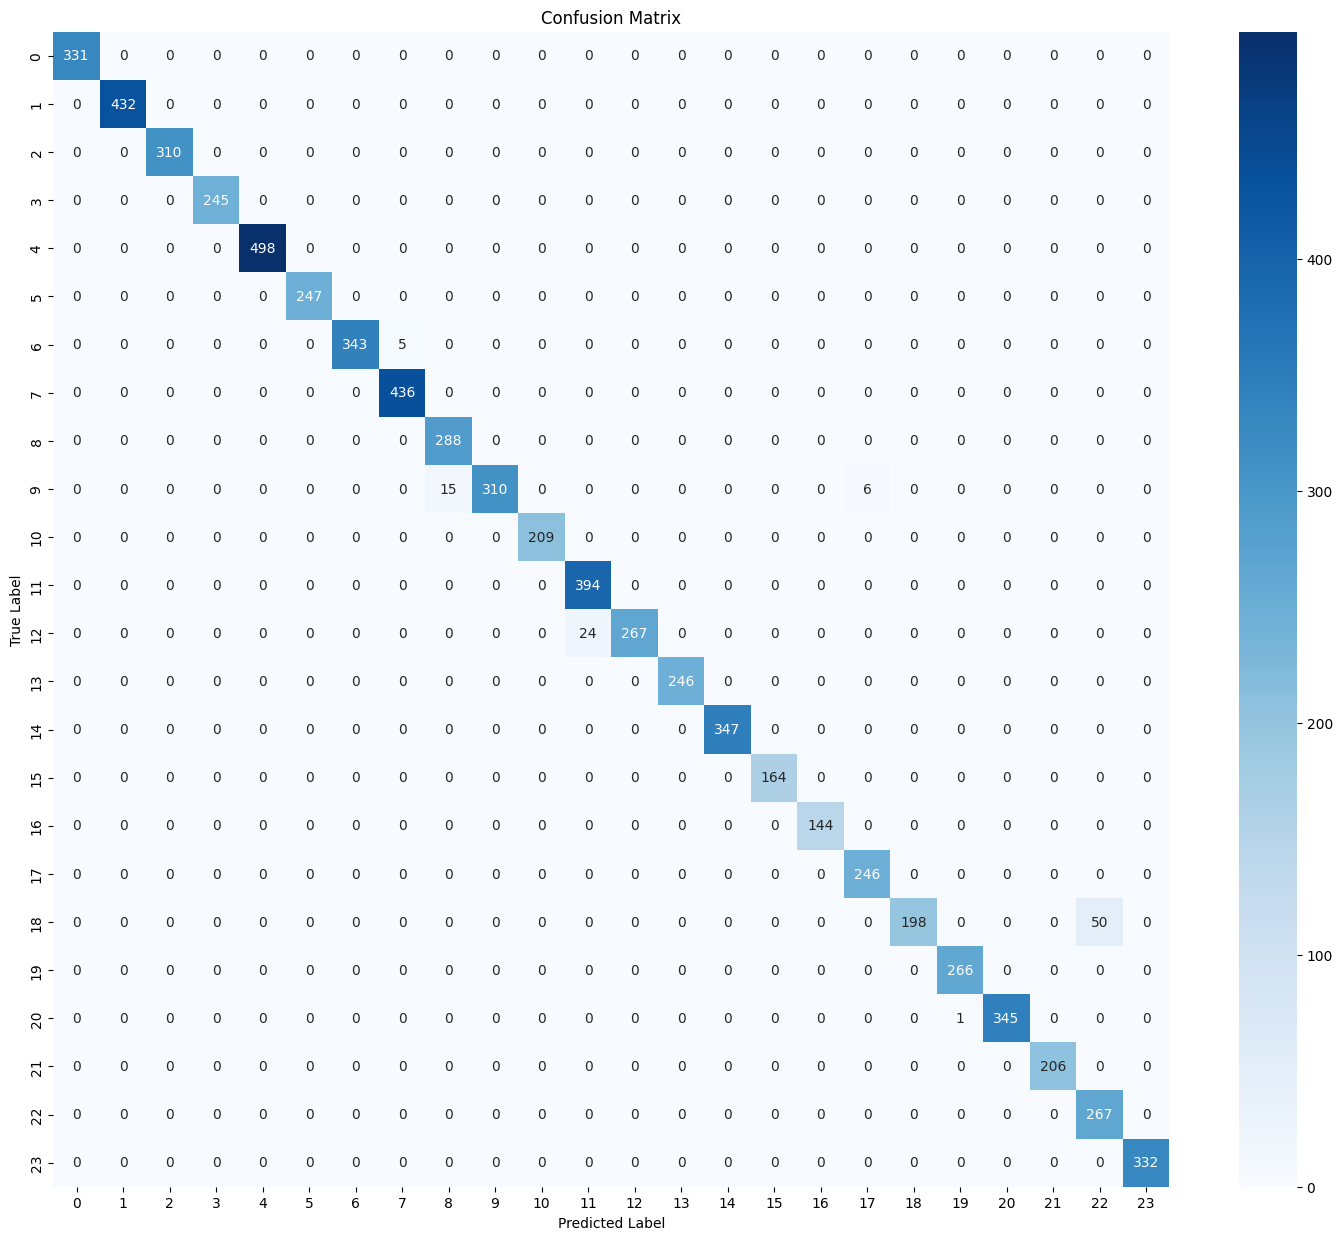

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

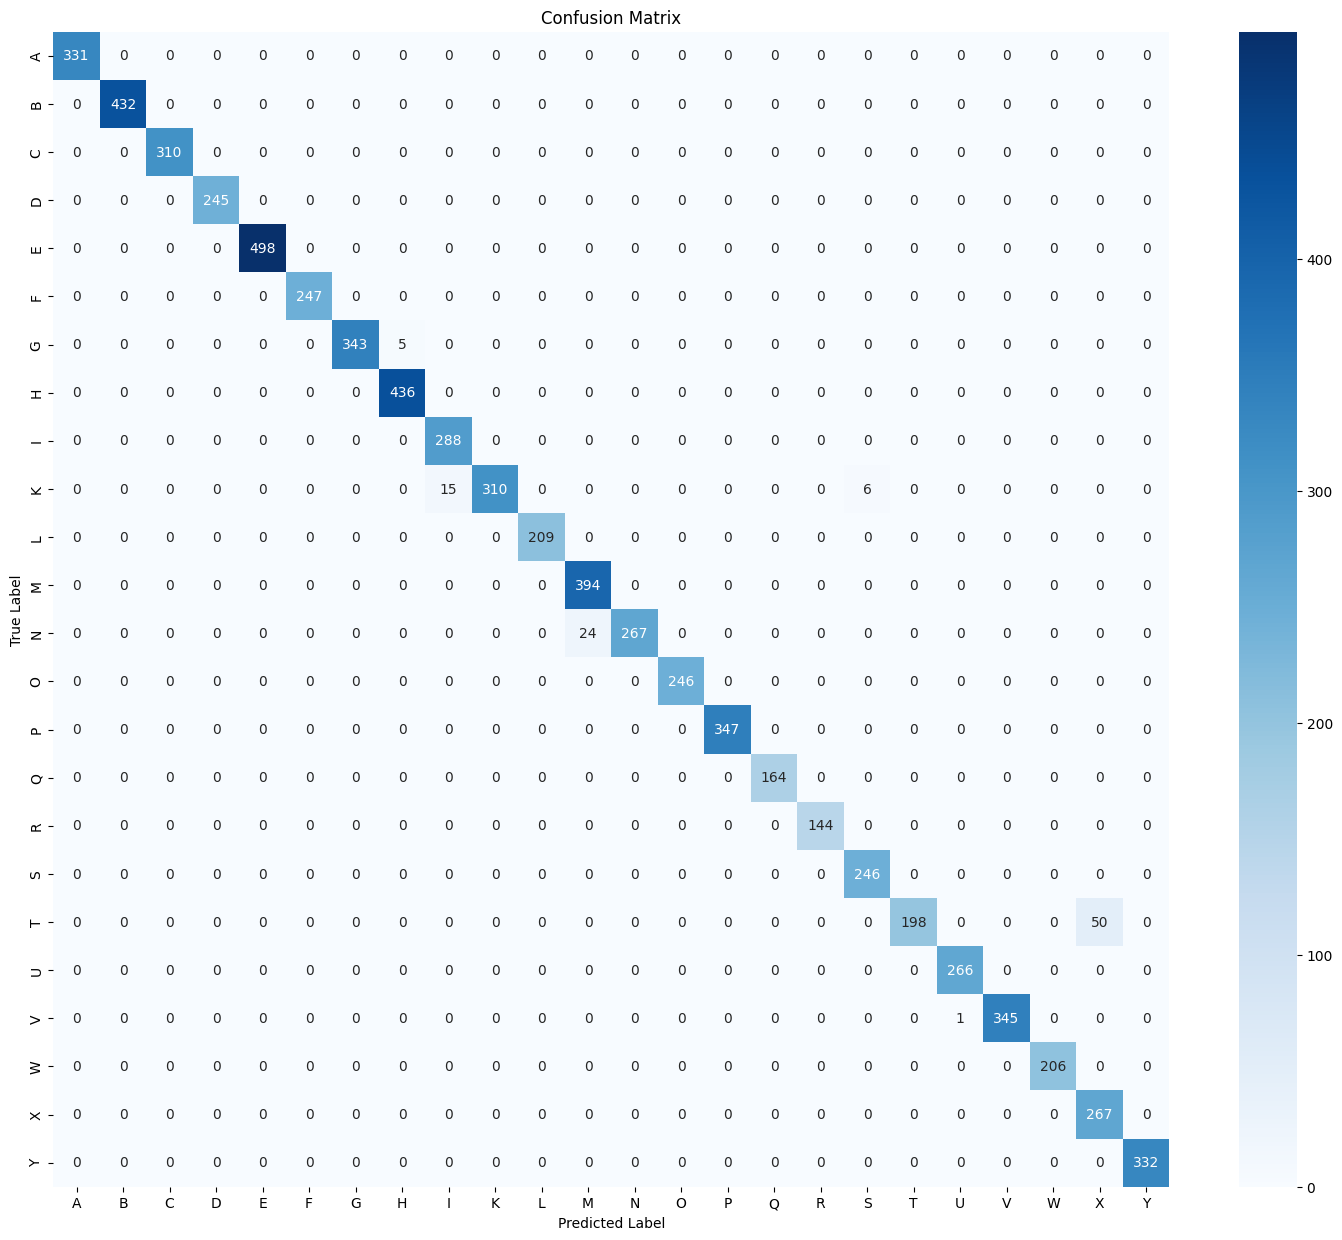

In [ ]:
asl_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=asl_labels, yticklabels=asl_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

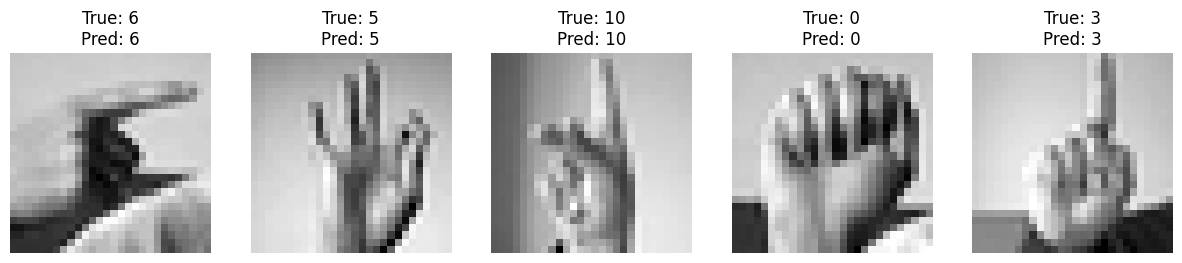

In [ ]:
# Displaying sample predictions

plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    plt.axis('off')
plt.show()